## CNN from scratch

In [1]:
import pandas as pd
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.regularizers import l2
from keras import Model, Sequential, layers, regularizers, optimizers
from tensorflow.keras.layers.experimental.preprocessing import Rescaling
from tensorflow.keras.callbacks import EarlyStopping
import pickle
from pickle import dump, load
from PIL import Image
from tqdm import tqdm
tqdm().pandas()
from google.cloud import storage
import requests
from io import BytesIO
import random


ModuleNotFoundError: No module named 'pandas'

In [2]:
storage_client = storage.Client("wagon-bootcamp-415720")
bucket = storage_client.get_bucket('covid19_lewagon')
blob = bucket.blob("COVID-19_Radiography_Dataset/Covid/COVID-1.png")
blob._get_download_url(storage_client)

'https://storage.googleapis.com/download/storage/v1/b/covid19_lewagon/o/COVID-19_Radiography_Dataset%2FCovid%2FCOVID-1.png?alt=media'

In [ ]:
def download_bucket_with_transfer_manager(
    bucket_name, destination_directory="", workers=8, max_results=1000
):
    from google.cloud.storage import Client, transfer_manager

    storage_client = Client()
    bucket = storage_client.bucket(bucket_name)

    blob_names = [blob.name for blob in bucket.list_blobs(max_results=max_results)]

    results = transfer_manager.download_many_to_path(
        bucket, blob_names, destination_directory=destination_directory, max_workers=workers
    )

    for name, result in zip(blob_names, results):
        # The results list is either `None` or an exception for each blob in
        # the input list, in order.

        if isinstance(result, Exception):
            print("Failed to download {} due to exception: {}".format(name, result))
        else:
            print("Downloaded {} to {}.".format(name, destination_directory + name))

In [ ]:
# download_bucket_with_transfer_manager(
#    'covid19_lewagon', destination_directory="/home/administrador/code/covid/Covid19/raw_data/cloud", workers=8, max_results=25500
# )

Downloaded COVID-19_Radiography_Dataset/COVID/COVID-1.png to /home/administrador/code/covid/Covid19/raw_data/cloudCOVID-19_Radiography_Dataset/COVID/COVID-1.png.
Downloaded COVID-19_Radiography_Dataset/COVID/COVID-10.png to /home/administrador/code/covid/Covid19/raw_data/cloudCOVID-19_Radiography_Dataset/COVID/COVID-10.png.
Downloaded COVID-19_Radiography_Dataset/COVID/COVID-100.png to /home/administrador/code/covid/Covid19/raw_data/cloudCOVID-19_Radiography_Dataset/COVID/COVID-100.png.
Downloaded COVID-19_Radiography_Dataset/COVID/COVID-1000.png to /home/administrador/code/covid/Covid19/raw_data/cloudCOVID-19_Radiography_Dataset/COVID/COVID-1000.png.
Downloaded COVID-19_Radiography_Dataset/COVID/COVID-1001.png to /home/administrador/code/covid/Covid19/raw_data/cloudCOVID-19_Radiography_Dataset/COVID/COVID-1001.png.
Downloaded COVID-19_Radiography_Dataset/COVID/COVID-1002.png to /home/administrador/code/covid/Covid19/raw_data/cloudCOVID-19_Radiography_Dataset/COVID/COVID-1002.png.
Down

In [ ]:
#Copiei as pastas das imagens coletadas depois para as pastas principais

# !cp -r /home/administrador/code/covid/Covid19/raw_data/cloud/xray-dataset-covid-pneumonia/Covid19_1 /home/administrador/code/covid/Covid19/raw_data/cloud/COVID-19_Radiography_Dataset/COVID
# !cp -r /home/administrador/code/covid/Covid19/raw_data/cloud/xray-dataset-covid-pneumonia/Covid19_2 /home/administrador/code/covid/Covid19/raw_data/cloud/COVID-19_Radiography_Dataset/COVID
# !cp -r /home/administrador/code/covid/Covid19/raw_data/cloud/xray-dataset-covid-pneumonia/Pneumonia /home/administrador/code/covid/Covid19/raw_data/cloud/COVID-19_Radiography_Dataset/Viral_Pneumonia

In [ ]:
import os
main_dir = "/home/administrador/code/covid/Covid19/raw_data/cloud/COVID-19_Radiography_Dataset"
covid = os.path.join(main_dir, "COVID")
normal = os.path.join(main_dir, "Normal")
pneumonia = os.path.join(main_dir, "Viral_Pneumonia")
opacity = os.path.join(main_dir, "Lung_Opacity")
covid_names = os.listdir(covid)
normal_names = os.listdir(normal)
pneumonia_names = os.listdir(pneumonia)
opacity_names = os.listdir(opacity)
print(len(covid_names))
print(len(normal_names))
print(len(pneumonia_names))
print(len(opacity_names))
print(len(covid_names)+len(normal_names)+len(pneumonia_names)+len(opacity_names))


4319
10192
4763
6012
25286


In [ ]:
covid_names = os.listdir(covid)
normal_names = os.listdir(normal)
pneumonia_names = os.listdir(pneumonia)
opacity_names = os.listdir(opacity)

## Train & test split

In [ ]:
import random
random.shuffle(covid_names)
random.shuffle(normal_names)
random.shuffle(pneumonia_names)
random.shuffle(opacity_names)
train_covid_names, test_covid_names = train_test_split(covid_names, test_size=0.20, random_state=42)
train_normal_names, test_normal_names = train_test_split(normal_names, test_size=0.20, random_state=42)
train_pneumonia_names, test_pneumonia_names = train_test_split(pneumonia_names, test_size=0.20, random_state=42)
train_opacity_names, test_opacity_names = train_test_split(opacity_names, test_size=0.20, random_state=42)

In [ ]:
print(len(train_covid_names), len(test_covid_names))
print(len(train_normal_names), len(test_normal_names))
print(len(train_pneumonia_names), len(test_pneumonia_names))
print(len(train_opacity_names), len(test_opacity_names))

3455 864
8153 2039
3810 953
4809 1203


## Create folders Train, Test and save images inside these folders

In [ ]:
cloud_dir = "/home/administrador/code/covid/Covid19/raw_data/cloud"
os.mkdir(cloud_dir + '/' + "train_test")

### -- Train

In [ ]:
train_test_dir = "/home/administrador/code/covid/Covid19/raw_data/cloud/train_test"
os.mkdir(train_test_dir + '/' + "train")

In [ ]:
train_dir = "/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train"
os.mkdir(train_dir + '/' + "COVID19")
for img_name in tqdm(train_covid_names):
    img = Image.open(os.path.join(covid, img_name))
    img = img.convert('RGB')
    img.save(train_dir+"/COVID19/"+img_name)

100%|██████████| 3455/3455 [02:56<00:00, 19.54it/s]


In [ ]:
os.mkdir(train_dir + '/' + "NORMAL")
for img_name in tqdm(train_normal_names):
    img = Image.open(os.path.join(normal, img_name))
    img.save(train_dir+"/NORMAL/"+img_name)

100%|██████████| 8153/8153 [03:33<00:00, 38.23it/s]


In [ ]:
os.mkdir(train_dir + '/' + "PNEUMONIA")
for img_name in tqdm(train_pneumonia_names):
    img = Image.open(os.path.join(pneumonia, img_name))
    img.save(train_dir+"/PNEUMONIA/"+img_name)

100%|██████████| 3810/3810 [01:46<00:00, 35.68it/s]


In [ ]:
os.mkdir(train_dir + '/' + "OPACITY")
for img_name in tqdm(train_opacity_names):
    img = Image.open(os.path.join(opacity, img_name))
    img.save(train_dir+"/OPACITY/"+img_name)

100%|██████████| 4809/4809 [02:06<00:00, 38.09it/s]


### -- Test

In [ ]:
train_test_dir = "/home/administrador/code/covid/Covid19/raw_data/cloud/train_test"
os.mkdir(train_test_dir + '/' + "test")

In [ ]:
test_dir = "/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/test"
os.mkdir(test_dir + '/' + "COVID19")
for img_name in tqdm(test_covid_names):
    img = Image.open(os.path.join(covid, img_name))
    img = img.convert('RGB')
    img.save(test_dir+"/COVID19/"+img_name)

100%|██████████| 864/864 [00:36<00:00, 23.80it/s]


In [ ]:
os.mkdir(test_dir + '/' + "NORMAL")
for img_name in tqdm(test_normal_names):
    img = Image.open(os.path.join(normal, img_name))
    img.save(test_dir+"/NORMAL/"+img_name)

100%|██████████| 2039/2039 [00:46<00:00, 44.16it/s]


In [ ]:
os.mkdir(test_dir + '/' + "PNEUMONIA")
for img_name in tqdm(test_pneumonia_names):
    img = Image.open(os.path.join(pneumonia, img_name))
    img.save(test_dir+"/PNEUMONIA/"+img_name)

100%|██████████| 953/953 [00:28<00:00, 33.84it/s]


In [ ]:
os.mkdir(test_dir + '/' + "OPACITY")
for img_name in tqdm(test_opacity_names):
    img = Image.open(os.path.join(opacity, img_name))
    img.save(test_dir+"/OPACITY/"+img_name)

100%|██████████| 1203/1203 [00:28<00:00, 41.73it/s]


## Visualization

In [4]:
train_dir = "/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train"
test_dir = "/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/test"

train_covid_dir = os.path.join(train_dir, "COVID19")
train_normal_dir = os.path.join(train_dir, "NORMAL")
train_pneumonia_dir = os.path.join(train_dir, "PNEUMONIA")
train_opacity_dir = os.path.join(train_dir, "OPACITY")
#directory with the testing images
test_covid_dir = os.path.join(test_dir, "COVID19")
test_normal_dir = os.path.join(test_dir, "NORMAL")
test_pneumonia_dir = os.path.join(test_dir, "PNEUMONIA")
test_opacity_dir = os.path.join(test_dir, "OPACITY")

['/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/COVID19/7a9ec606.png', '/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/COVID19/COVID-1205.png', '/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/COVID19/COVID-577.png', '/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/COVID19/COVID-603.png']
['/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/NORMAL/Normal-4861.png', '/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/NORMAL/Normal-9776.png', '/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/NORMAL/Normal-9772.png', '/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/NORMAL/Normal-4791.png']
['/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/PNEUMONIA/PNEUMONIA(3306).jpg', '/home/administrador/code/covid/Covid19/raw_data/cloud/train_test/train/PNEUMONIA/PNEUMONIA(2979).jpg', '/home/administra

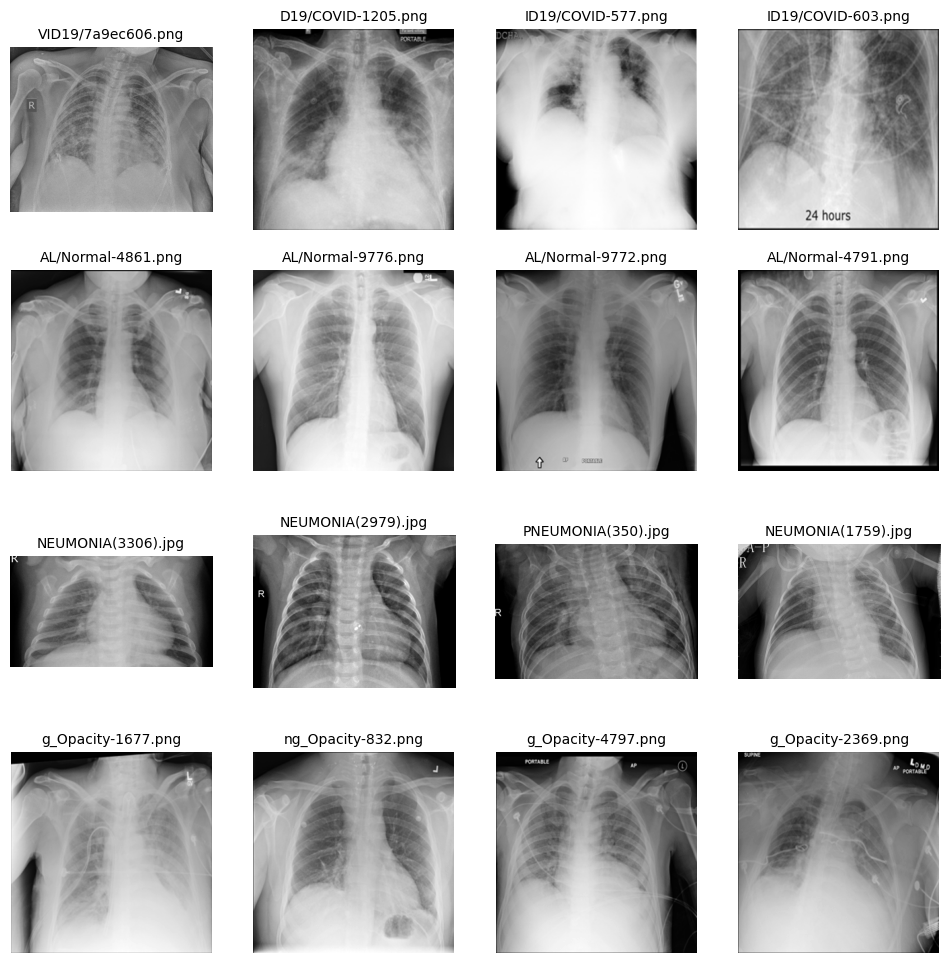

In [ ]:
# plot a grid of 16 images
import matplotlib.image as mpimg

#set the number of columns and rows
rows = 4
cols = 4

#set the figure size
fig = plt.gcf()
fig.set_size_inches(12,12)

#get the filenames
covid_pic = [os.path.join(train_covid_dir, filename) for filename in train_covid_names[0:4]]
normal_pic = [os.path.join(train_normal_dir, filename) for filename in train_normal_names[0:4]]
pneumonia_pic = [os.path.join(train_pneumonia_dir, filename) for filename in train_pneumonia_names[0:4]]
opacity_pic = [os.path.join(train_opacity_dir, filename) for filename in train_opacity_names[0:4]]
#print the list
print(covid_pic)
print(normal_pic)
print(pneumonia_pic)
print(opacity_pic)
#merge the list
merged_list = covid_pic+normal_pic+pneumonia_pic+opacity_pic
for i, img_path in enumerate(merged_list):
  data = img_path.split("/",6)[6]
  sp = plt.subplot(rows, cols, i+1)
  sp.axis("off")
  img = mpimg.imread(img_path)
  sp.set_title(data[-18:], fontsize=10)
  plt.imshow(img, cmap="gray")
plt.show()

## Data Preprocessing

In [ ]:
def smallest_image(directory):
    smallest_image = None
    name_smallest_image = None

    # Iterar sobre os arquivos no diretório
    for dir in glob(f'{directory}/*/'):
        for file in os.listdir(dir):
            file_path = os.path.join(dir, file)

            # Carregar a imagem usando o TensorFlow
            imagem = tf.io.read_file(file_path)
            imagem = tf.io.decode_image(imagem, channels=3)

            # Obter as dimensões da imagem
            height, width, _ = imagem.shape

            # Comparar com a menor imagem encontrada até agora
            actual_size = height * width
            if smallest_image is None or actual_size < smallest_image:
                smallest_image = actual_size
                name_smallest_image = file

    #return name_smallest_image, smallest_image
    return name_smallest_image, height, width


In [ ]:
# Caminho para o diretório que contém as imagens
name_smallest_image, height, width = smallest_image(main_dir)
print(name_smallest_image, height, width)

PNEUMONIA(2635).jpg 299 299


In [5]:
dgen_train = ImageDataGenerator(rescale = 1./255,
                                validation_split=0.2,
                                shear_range=0.2,
                                zoom_range = 0.2,
                                horizontal_flip = False)
dgen_validation = ImageDataGenerator(rescale = 1./255)
dgen_test = ImageDataGenerator(rescale=1./255)

train_generator = dgen_train.flow_from_directory(train_dir,
                                                 target_size=(150,150),
                                                 subset = "training",
                                                 batch_size = 32,
                                                 class_mode = "categorical")

validation_generator = dgen_train.flow_from_directory(train_dir,
                                                 target_size=(150,150),
                                                 subset = "validation",
                                                 batch_size = 32,
                                                 class_mode = "categorical")

test_generator = dgen_test.flow_from_directory(test_dir,
                                                 target_size=(150,150),
                                                 batch_size = 32,
                                                 class_mode = "categorical")


Found 16183 images belonging to 4 classes.
Found 4044 images belonging to 4 classes.
Found 5059 images belonging to 4 classes.


In [9]:
X_train, y_train = train_generator.next()
X_val, y_val = validation_generator.next()
X_test, y_test = test_generator.next()

AttributeError: 'DirectoryIterator' object has no attribute 'next'

In [ ]:
train_generator.class_indices

## Building CNN

In [ ]:
model = Sequential()
model.add(Rescaling(1./255, input_shape=train_generator.image_shape))

model.add(layers.Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.2))

model.add(layers.Conv2D(64, kernel_size=(3,3), padding='same', activation="relu"))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Dropout(0.2))

model.add(layers.Conv2D(128, kernel_size=(3,3), padding='same', activation="relu"))
model.add(layers.MaxPooling2D(2))
model.add(layers.Dropout(0.2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

model.add(layers.Dense(4, activation='softmax'))


print("✅ Model initialized")
print(model.summary)

In [ ]:
learning_rate=1e-4
opt = optimizers.Adam(learning_rate=learning_rate)
model.compile(loss='categorical_crossentropy',
                optimizer=opt,
                metrics=['accuracy'])

## Fit & Evaluate

In [ ]:
epochs = 30
batch_size = 16

In [ ]:
es = EarlyStopping(monitor = 'val_loss',
                   patience = 5,
                   verbose = 1,
                   restore_best_weights = True)

In [ ]:
history = model.fit(train_generator,
                    epochs = epochs,
                    batch_size = batch_size,
                    validation_data = validation_generator,
                    callbacks=[es])

In [ ]:
#model = load_model(main_dir + '/' + "models/model1.h5")

In [ ]:
#get the keys of history object
history.history.keys()

In [ ]:
#plot graph between training and validation loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["Training", "Validation"])
plt.title("Training and validation losses")
plt.xlabel("epoch")

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Training", "Validation"])
plt.title("Training and validation accuracy")
plt.xlabel("epoch")

In [ ]:
# get the test acuarcy and loss
test_loss, test_acc = model.evaluate(test_generator)
print("test loss :{} test acc : {}".format(test_loss,test_acc))

In [ ]:
from google.colab import files
from keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import Model, load_model

main_dir = "/content/drive/My Drive/data/viral/COVID-19_Radiography_Dataset/"
model = load_model(main_dir + '/' + "models/model.h5")

uploaded = files.upload()
for filename in uploaded.keys():
  img_path = "/content/drive/My Drive/data/viral/covid_examples/"+filename
  img = image.load_img(img_path, target_size=(150,150))
  images = image.img_to_array(img)
  images = np.expand_dims(images, axis=0)
  prediction = model.predict(images)
  print(filename)
  print(prediction)